<a href="https://colab.research.google.com/github/Monitha-SureshBabu/Aletheia-CEO/blob/main/Fuel_price_prediciton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sample Data (last 8 years):
 Year  Fuel_Price_INR  Fuel_Smooth
 2019       65.661186    67.839923
 2020       53.847100    81.893510
 2021       90.146618    88.356594
 2022      126.730728    95.776034
 2023      105.397338   101.662134
 2024      102.758385   102.109217
 2025       83.277603    95.953839
 2026       92.382029    92.806006

Total years: 57

Linear Regression  → R²: 0.8053 | MAE: ₹13.70/litre
🔮 2035 Prediction : ₹108.83 per litre


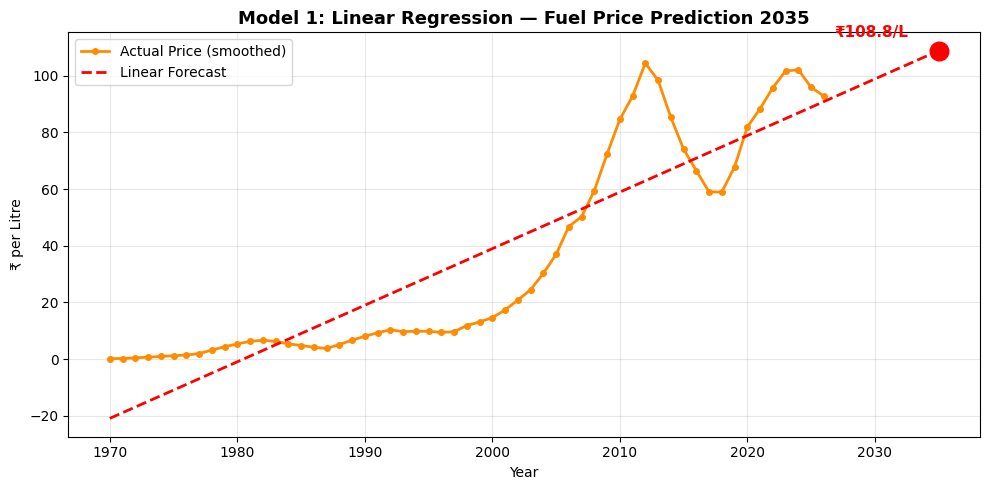


Polynomial (deg 2) → R²: 0.8738 | MAE: ₹8.81/litre
🔮 2035 Prediction : ₹152.30 per litre


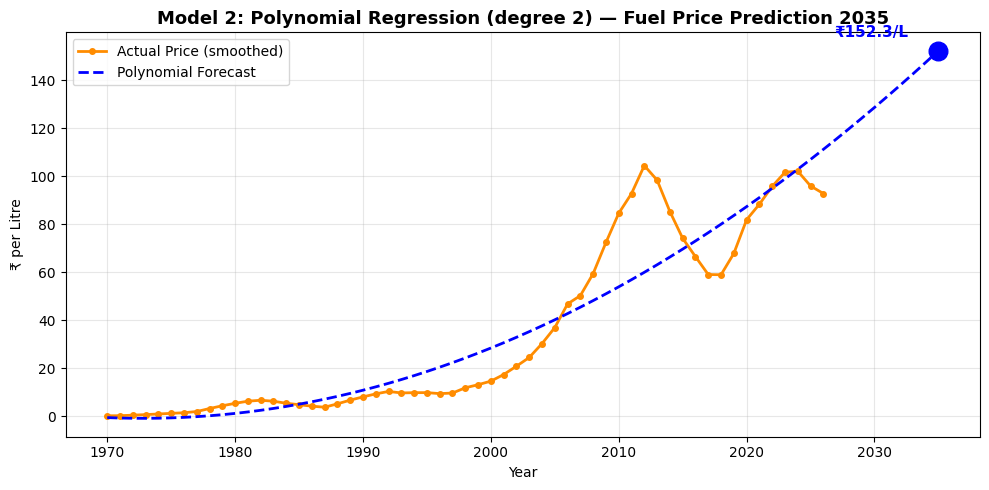

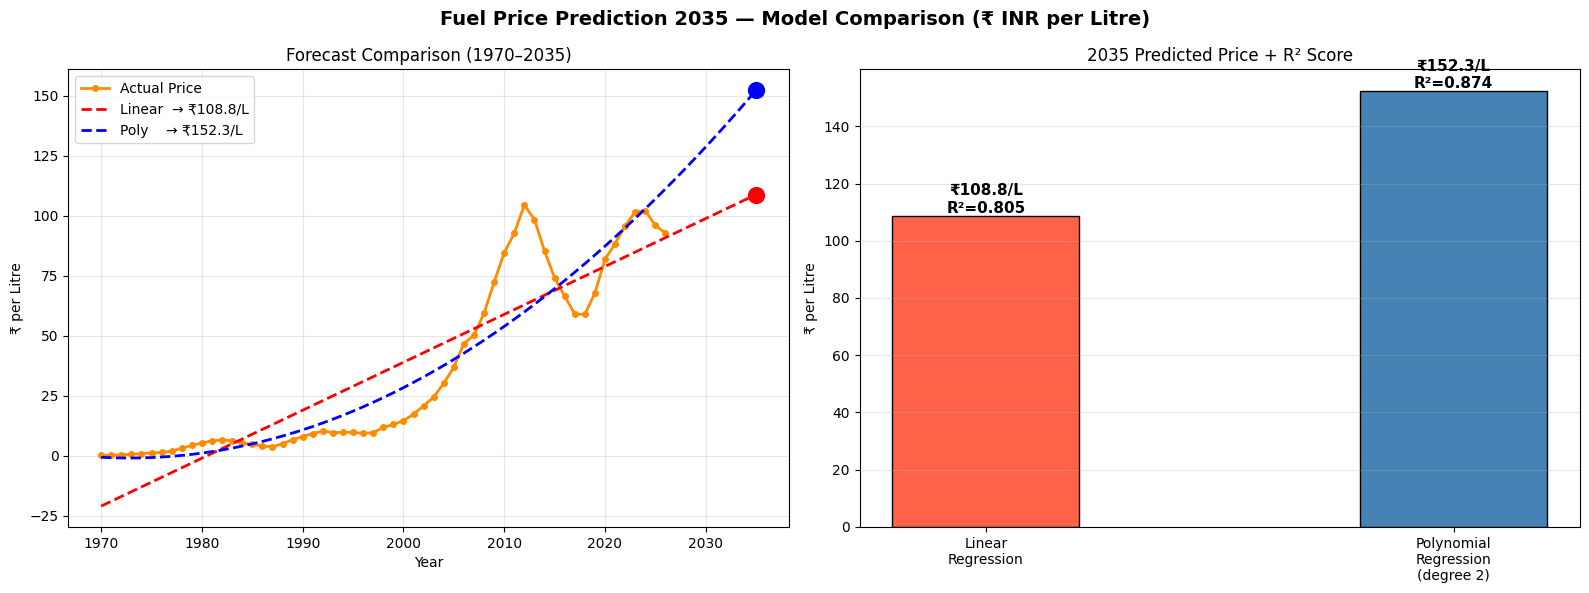


    FUEL PRICE PREDICTION 2035 — FINAL SUMMARY
  Dataset  : Crude Oil 1970–2026 → INR/Litre
  Feature  : Year (single input)
  Target   : Fuel Price (₹ per Litre, 5yr smoothed)

  Model 1 — Linear Regression
    R²     : 0.8053
    MAE    : ₹13.70 per litre
    2035   : ₹108.83 per litre

  Model 2 — Polynomial Regression (degree 2)
    R²     : 0.8738
    MAE    : ₹8.81 per litre
    2035   : ₹152.30 per litre

  ✅ Better Model : Polynomial Regression
     Higher R²   : 0.8738
     Lower MAE   : ₹8.81/litre


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error

# ── STEP 1: Load & Prepare Data ─────────────────────────────
df = pd.read_csv('/content/sample_data/fuel_prices_1970_2026.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year


df_yearly = df.groupby('Year')['Crude_Oil_Price'].mean().reset_index()
df_yearly.columns = ['Year', 'Crude_Oil_USD']


def convert_to_inr(row):
    year = row['Year']
    usd  = row['Crude_Oil_USD']
    if year < 1980:   usd_inr = 8.0
    elif year < 1990: usd_inr = 13.0
    elif year < 2000: usd_inr = 35.0
    elif year < 2010: usd_inr = 46.0
    elif year < 2020: usd_inr = 68.0
    else:             usd_inr = 83.0
    return (usd * usd_inr / 158.987) * 2.5

df_yearly['Fuel_Price_INR'] = df_yearly.apply(convert_to_inr, axis=1)


df_yearly['Fuel_Smooth'] = df_yearly['Fuel_Price_INR'].rolling(5, center=True, min_periods=1).mean()

print("Sample Data (last 8 years):")
print(df_yearly[['Year','Fuel_Price_INR','Fuel_Smooth']].tail(8).to_string(index=False))
print(f"\nTotal years: {len(df_yearly)}")

X      = df_yearly[['Year']].values
y      = df_yearly['Fuel_Smooth'].values
future = np.arange(1970, 2036).reshape(-1, 1)

# ── STEP 2: Linear Regression ────────────────────────────────
lr = LinearRegression()
lr.fit(X, y)

y_pred_lr      = lr.predict(X)
future_pred_lr = lr.predict(future)
pred_2035_lr   = lr.predict([[2035]])[0]

r2_lr  = r2_score(y, y_pred_lr)
mae_lr = mean_absolute_error(y, y_pred_lr)

print(f"\nLinear Regression  → R²: {r2_lr:.4f} | MAE: ₹{mae_lr:.2f}/litre")
print(f"🔮 2035 Prediction : ₹{pred_2035_lr:.2f} per litre")

# Graph 1
plt.figure(figsize=(10, 5))
plt.plot(df_yearly['Year'], y, 'o-', color='darkorange', lw=2, ms=4, label='Actual Price (smoothed)')
plt.plot(future, future_pred_lr, 'r--', lw=2, label='Linear Forecast')
plt.scatter([2035], [pred_2035_lr], color='red', s=180, zorder=6)
plt.annotate(f'₹{pred_2035_lr:.1f}/L',
             xy=(2035, pred_2035_lr),
             xytext=(-75, 10), textcoords='offset points',
             color='red', fontsize=11, fontweight='bold')
plt.title('Model 1: Linear Regression — Fuel Price Prediction 2035',
          fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('₹ per Litre')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fuel_linear.png', dpi=150)
plt.show()

# ── STEP 3: Polynomial Regression (degree 2) ─────────────────
poly   = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

pr = LinearRegression()
pr.fit(X_poly, y)

y_pred_poly      = pr.predict(X_poly)
future_pred_poly = pr.predict(poly.transform(future))
pred_2035_poly   = pr.predict(poly.transform([[2035]]))[0]

r2_poly  = r2_score(y, y_pred_poly)
mae_poly = mean_absolute_error(y, y_pred_poly)

print(f"\nPolynomial (deg 2) → R²: {r2_poly:.4f} | MAE: ₹{mae_poly:.2f}/litre")
print(f"🔮 2035 Prediction : ₹{pred_2035_poly:.2f} per litre")

# Graph 2
plt.figure(figsize=(10, 5))
plt.plot(df_yearly['Year'], y, 'o-', color='darkorange', lw=2, ms=4, label='Actual Price (smoothed)')
plt.plot(future, future_pred_poly, 'b--', lw=2, label='Polynomial Forecast')
plt.scatter([2035], [pred_2035_poly], color='blue', s=180, zorder=6)
plt.annotate(f'₹{pred_2035_poly:.1f}/L',
             xy=(2035, pred_2035_poly),
             xytext=(-75, 10), textcoords='offset points',
             color='blue', fontsize=11, fontweight='bold')
plt.title('Model 2: Polynomial Regression (degree 2) — Fuel Price Prediction 2035',
          fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('₹ per Litre')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fuel_polynomial.png', dpi=150)
plt.show()

# ── STEP 4: Comparison Chart ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Fuel Price Prediction 2035 — Model Comparison (₹ INR per Litre)',
             fontsize=14, fontweight='bold')

# Left panel
axes[0].plot(df_yearly['Year'], y, 'o-', color='darkorange',
             lw=2, ms=4, label='Actual Price')
axes[0].plot(future, future_pred_lr,   'r--', lw=2,
             label=f'Linear  → ₹{pred_2035_lr:.1f}/L')
axes[0].plot(future, future_pred_poly, 'b--', lw=2,
             label=f'Poly    → ₹{pred_2035_poly:.1f}/L')
axes[0].scatter([2035], [pred_2035_lr],   color='red',  s=130, zorder=6)
axes[0].scatter([2035], [pred_2035_poly], color='blue', s=130, zorder=6)
axes[0].set_title('Forecast Comparison (1970–2035)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('₹ per Litre')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right panel
models = ['Linear\nRegression', 'Polynomial\nRegression\n(degree 2)']
preds  = [pred_2035_lr, pred_2035_poly]
r2s    = [r2_lr, r2_poly]
bars   = axes[1].bar(models, preds,
                     color=['tomato', 'steelblue'],
                     width=0.4, edgecolor='black')
for bar, val, r2 in zip(bars, preds, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1,
                 f'₹{val:.1f}/L\nR²={r2:.3f}',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('2035 Predicted Price + R² Score')
axes[1].set_ylabel('₹ per Litre')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fuel_comparison.png', dpi=150)
plt.show()

# ── STEP 5: Final Summary ─────────────────────────────────────
print("\n" + "=" * 52)
print("    FUEL PRICE PREDICTION 2035 — FINAL SUMMARY")
print("=" * 52)
print(f"  Dataset  : Crude Oil 1970–2026 → INR/Litre")
print(f"  Feature  : Year (single input)")
print(f"  Target   : Fuel Price (₹ per Litre, 5yr smoothed)")
print()
print(f"  Model 1 — Linear Regression")
print(f"    R²     : {r2_lr:.4f}")
print(f"    MAE    : ₹{mae_lr:.2f} per litre")
print(f"    2035   : ₹{pred_2035_lr:.2f} per litre")
print()
print(f"  Model 2 — Polynomial Regression (degree 2)")
print(f"    R²     : {r2_poly:.4f}")
print(f"    MAE    : ₹{mae_poly:.2f} per litre")
print(f"    2035   : ₹{pred_2035_poly:.2f} per litre")
print()
winner_r2  = "Polynomial" if r2_poly > r2_lr else "Linear"
winner_mae = "Polynomial" if mae_poly < mae_lr else "Linear"
print(f"  ✅ Better Model : {winner_r2} Regression")
print(f"     Higher R²   : {max(r2_lr, r2_poly):.4f}")
print(f"     Lower MAE   : ₹{min(mae_lr, mae_poly):.2f}/litre")
print("=" * 52)